In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

## 문제 1.Titanic 데이터를 불러와 상위 10개 행을 출력하시오.

In [1]:
import pandas as pd
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## 문제 2. 각 컬럼의 데이터 타입과 Non-Null 개수를 확인하시오.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 문제 3. 수치형 컬럼들의 기술통계량을 확인하시오.

In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 문제 4. 결측치가 존재하는 컬럼명과 결측치 개수를 내림차순으로 출력하시오.

In [21]:
na_list = pd.Series(df[df.columns[df.isnull().any()]].isnull().sum()).sort_values(ascending=False)
na_list

Cabin       687
Age         177
Embarked      2
dtype: int64

## 문제 5. 결측치 비율(%)을 계산하여 출력하시오.

In [106]:
na_percent = na_list / df.shape[0]
na_percent

Cabin       0.771044
Age         0.198653
Embarked    0.002245
dtype: float64

## 문제 6.Cabin 컬럼의 결측치 비율을 확인하고 50% 이상이면 컬럼 자체를 제거하시오.

In [27]:
if na_percent['Cabin'] > 0.5 :
    df = df.drop('Cabin', axis=1)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## 문제 7.Age 결측치는 평균값으로 대체하고 Fare 결측치는 중앙값으로 대체하시오.

In [30]:
df['Fare']

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

In [33]:
df = df.fillna(
                {'Age' : df['Age'].mean(),
                 'Fare' : df['Fare'].median()
                } 
              )

## 문제 8. PassengerId, Name, Ticket 컬럼을 제거하시오.

In [35]:
df_drop = df.drop(columns=['PassengerId', 'Name', 'Ticket'], axis=1)
df_drop

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.000000,1,0,7.2500,S
1,1,1,female,38.000000,1,0,71.2833,C
2,1,3,female,26.000000,0,0,7.9250,S
3,1,1,female,35.000000,1,0,53.1000,S
4,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S
887,1,1,female,19.000000,0,0,30.0000,S
888,0,3,female,29.699118,1,2,23.4500,S
889,1,1,male,26.000000,0,0,30.0000,C


## 문제 9.성별(Sex)에 따른 생존율을 계산하시오.

In [36]:
df_drop.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

## 문제 10.객실등급(Pclass)에 따른 생존율을 계산하시오.

In [37]:
df_drop.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

## 문제 11.성별별 승객 수를 Countplot으로 시각화하시오.

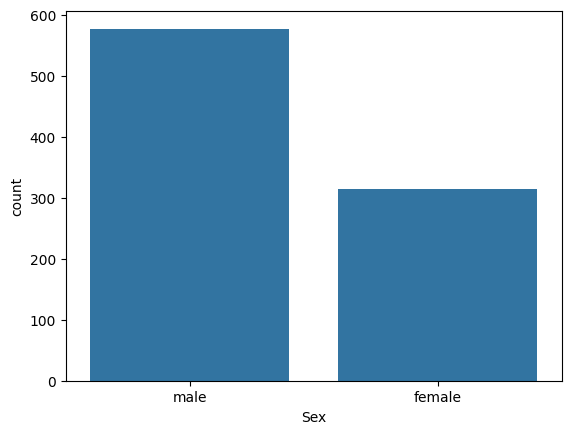

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df_drop, x='Sex')
plt.show()

## 문제 12.Fare 컬럼의 분포를 Histogram으로 시각화하시오.

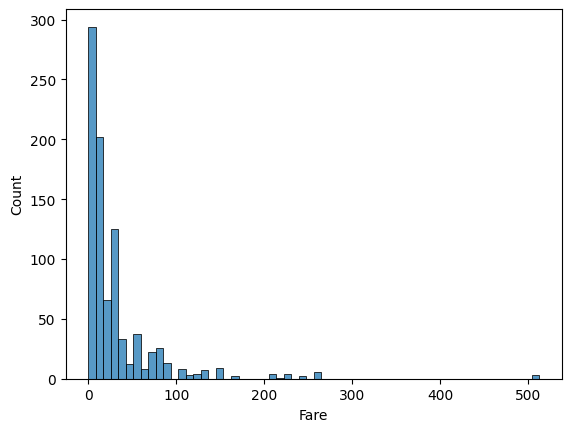

In [111]:
# sns.histplot(data=df_drop, x='Fare', bins=15)
sns.histplot(df_drop['Fare'])
plt.show()

## 문제 13.Age와 Fare의 관계를 Scatter Plot으로 시각화하시오.

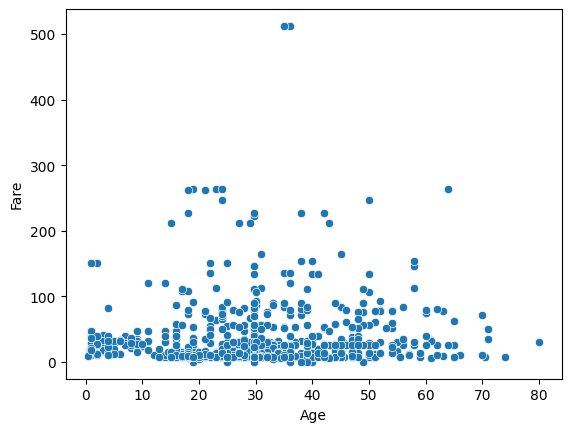

In [49]:
sns.scatterplot(data=df_drop, x='Age', y='Fare')
plt.show()

## 문제 14.Sex, Embarked 컬럼을 One-Hot Encoding 하시오.
- 조건 : `drop_first=True`

In [50]:
ohe_list = ['Sex', 'Embarked']
df_ohe = pd.get_dummies(data=df_drop, columns=ohe_list, drop_first=True, prefix=ohe_list)
df_ohe

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.000000,1,0,7.2500,True,False,True
1,1,1,38.000000,1,0,71.2833,False,False,False
2,1,3,26.000000,0,0,7.9250,False,False,True
3,1,1,35.000000,1,0,53.1000,False,False,True
4,0,3,35.000000,0,0,8.0500,True,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,True,False,True
887,1,1,19.000000,0,0,30.0000,False,False,True
888,0,3,29.699118,1,2,23.4500,False,False,True
889,1,1,26.000000,0,0,30.0000,True,False,False


## 문제 15.Survived를 타겟으로 지정하고 나머지 컬럼을 Feature로 지정하시오.

In [51]:
X = df_ohe.drop('Survived', axis=1)
y = df_ohe['Survived']

## 문제 16.Train/Test를 아래 조건으로 분리하시오.
- 조건 : `test_size=0.3`, `random_state=123`, `stratify=y`

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)

## 문제 17.MinMaxScaler를 사용하여 Feature를 스케일링하시오.

In [53]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 문제 18.Logistic Regression 모델을 생성하시오.
- 조건 : `random_state=123`, `max_iter=1000`

In [127]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(random_state=123, max_iter=1000)

## 문제 19.모델을 학습시키고 테스트 데이터를 예측하시오.

In [128]:
model_lr.fit(X_train_scaled, y_train)
y_pred = model_lr.predict(X_test_scaled)

## 문제 20.Accuracy를 출력하시오.

In [129]:
from sklearn.metrics import accuracy_score
print(f'Accuracy : {accuracy_score(y_test, y_pred)}')

Accuracy : 0.7873134328358209


## 문제 21.Confusion Matrix를 출력하시오.

In [59]:
from sklearn.metrics import confusion_matrix
print(f'Confusion Matrix : {confusion_matrix(y_test, y_pred)}')

Confusion Matrix : [[143  22]
 [ 35  68]]


## 문제 22.Classification Report를 출력하시오.

In [62]:
from sklearn.metrics import classification_report
print('Classification Report :')
print(classification_report(y_test, y_pred))

Classification Report :
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       165
           1       0.76      0.66      0.70       103

    accuracy                           0.79       268
   macro avg       0.78      0.76      0.77       268
weighted avg       0.78      0.79      0.78       268



## 문제 23.예측 확률(predict_proba)을 출력하시오.
- 생존할 확률만 출력할 것.

In [113]:
y_pred_proba = model.predict_proba(X_test_scaled)
y_pred_proba[:, 1]

array([0.21373347, 0.88959399, 0.14158559, 0.10156137, 0.21734627,
       0.67700555, 0.36105261, 0.07885163, 0.91714204, 0.41224049,
       0.76121677, 0.94260525, 0.75735413, 0.40098641, 0.65160918,
       0.81183484, 0.2902248 , 0.21373347, 0.12176209, 0.89335838,
       0.19330467, 0.28786926, 0.10156137, 0.12362213, 0.83205185,
       0.07500386, 0.14357405, 0.62561842, 0.33070307, 0.17575487,
       0.81925956, 0.33554104, 0.43924252, 0.07366055, 0.86293266,
       0.08083573, 0.40488256, 0.65164041, 0.5892811 , 0.77663169,
       0.10154771, 0.08083573, 0.92432834, 0.13180645, 0.12510737,
       0.60320858, 0.94646755, 0.7628872 , 0.49649528, 0.10821499,
       0.90443582, 0.10821499, 0.08952685, 0.17683294, 0.0784729 ,
       0.57997968, 0.11638476, 0.21498374, 0.44030368, 0.0330713 ,
       0.1643358 , 0.09602508, 0.12224314, 0.13743138, 0.63900346,
       0.10161565, 0.49649528, 0.75735413, 0.12227961, 0.60412276,
       0.12168856, 0.14091095, 0.10327967, 0.32919298, 0.32460

## 문제 24.생존 확률이 가장 높은 상위 10명의 확률을 출력하시오.

In [118]:
pd.Series(y_pred_proba[:, 1]).sort_values(ascending=False)[:10]

77     0.950582
46     0.946468
11     0.942605
160    0.941873
247    0.934589
84     0.925938
124    0.924817
42     0.924328
187    0.918184
8      0.917142
dtype: float64

## 문제 25.ROC-AUC Score를 계산하시오.

In [131]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred_proba[:, 1])

np.float64(0.8457781700500148)

# 추가심화문제
## 문제 26.Age를 아래 기준으로 범주화하여 Age_Group 컬럼을 생성하시오.
- 0~19 : Teen
- 20~39 : Young Adult
- 40~59 : Adult
- 60+ : Senior

In [121]:
def make_age_group(age) :
    if age >= 60:
        return 'Senior'
    elif age >= 40:
        return 'Adult'
    elif age >= 20:
        return 'Young Adult'
    else:
        return 'Teen'

df_ohe['Age_Group'] = df_ohe['Age'].apply(make_age_group)
df_ohe.head(10)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Age_Group
0,0,3,22.000000,1,0,7.2500,True,False,True,Young Adult
1,1,1,38.000000,1,0,71.2833,False,False,False,Young Adult
2,1,3,26.000000,0,0,7.9250,False,False,True,Young Adult
3,1,1,35.000000,1,0,53.1000,False,False,True,Young Adult
4,0,3,35.000000,0,0,8.0500,True,False,True,Young Adult
5,0,3,29.699118,0,0,8.4583,True,True,False,Young Adult
6,0,1,54.000000,0,0,51.8625,True,False,True,Adult
7,0,3,2.000000,3,1,21.0750,True,False,True,Teen
8,1,3,27.000000,0,2,11.1333,False,False,True,Young Adult
9,1,2,14.000000,1,0,30.0708,False,False,False,Teen


## 문제 27.Age_Group별 생존율을 계산하시오.

In [122]:
df_ohe.groupby('Age_Group')['Survived'].mean()

Age_Group
Adult          0.394161
Senior         0.269231
Teen           0.481707
Young Adult    0.358156
Name: Survived, dtype: float64

## 문제 28.Pclass와 Sex를 기준으로 생존율 Pivot Table을 생성하시오.

In [134]:
pd.pivot_table(data=df, values='Survived', index='Pclass', columns='Sex')

Sex,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


## 문제 29.Fare 상위 10% 승객만 추출하시오.

In [138]:
# GPT 정답
threshold = df['Fare'].quantile(0.9)

top10 = df[
    df['Fare'] >= threshold
]

top10.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.000000,3,2,19950,263.0000,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,29.699118,1,0,PC 17569,146.5208,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.000000,1,0,PC 17604,82.1708,C
61,62,1,1,"Icard, Miss. Amelie",female,38.000000,0,0,113572,80.0000,NaN
62,63,0,1,"Harris, Mr. Henry Birkhardt",male,45.000000,1,0,36973,83.4750,S


In [141]:
print(df.shape[0] * 0.1)
df.sort_values(by='Fare', ascending=False).head()

89.10000000000001


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,S


## 문제 30.RandomForestClassifier를 사용하여 모델을 학습하고 Logistic Regression의 Accuracy와 비교하시오.

In [142]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=123)
model_rf.fit(X_train_scaled, y_train)
y_pred_rf = model_rf.predict(X_test_scaled)

print(f'Logistic Accuaracy: {accuracy_score(y_test, y_pred)}')
print(f'RandomForest Accuaracy: {accuracy_score(y_test, y_pred_rf)}')

Logistic Accuaracy: 0.7873134328358209
RandomForest Accuaracy: 0.7835820895522388
